Data Cleaning

In [169]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as smf2
import matplotlib.pyplot as plt
import xgboost as xgb

In [170]:
df = pd.read_csv("Finalized_Edited_Dataset.csv", encoding="latin1")
df.head()

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Guaranteed
0,A.J. Green,29.100000,26,MIL,SG,78,68,3.4,7.9,0.424,...,10.400000,NaN,MIL,2301587.0,10044644.0,10848215.0,11651786.0,12455355.0,NaN,47301587.0
1,Aaron Gordon,27.900000,30,DEN,PF,36,33,5.5,11.1,0.497,...,16.200001,NaN,DEN,22841455.0,33658037.0,36350680.0,39043323.0,NaN,NaN,92850172.0
2,Aaron Holiday,13.700000,29,HOU,PG,57,1,1.8,4.4,0.417,...,5.500000,NaN,HOU,2296274.0,NaN,NaN,NaN,NaN,NaN,2296274.0
3,Aaron Nesmith,29.700001,26,IND,SF,45,42,4.7,11.4,0.414,...,13.800000,NaN,IND,11000000.0,11000000.0,19418000.0,20971440.0,NaN,NaN,62389440.0
4,Aaron Wiggins,21.799999,27,OKC,SG,65,21,3.6,8.2,0.431,...,9.400000,NaN,OKC,10102803.0,9224300.0,8345797.0,8345797.0,NaN,NaN,27672900.0


In [171]:
df["Player"].value_counts()

Player
Garrison Mathews          3
Jeremiah Robinson-Earl    3
Kobe Bufkin               3
Tony Bradley              3
Jeremy Sochan             2
                         ..
Andrew Wiggins            1
Anfernee Simons           1
Anthony Black             1
Anthony Davis             1
Trayce Jackson-Davis      1
Name: count, Length: 405, dtype: int64

After checking for duplicate names, I realized that some players were listed in the dataset 2-3 times.

In [172]:
df[df["Player"] == "Garrison Mathews"]

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Guaranteed
131,Garrison Mathews,13.1,29,IND,SG,15,1,1.4,3.5,0.404,...,5.2,NaN,IND,429325.0,NaN,NaN,NaN,NaN,NaN,561295.0
132,Garrison Mathews,13.1,29,IND,SG,15,1,1.4,3.5,0.404,...,5.2,NaN,IND,429325.0,NaN,NaN,NaN,NaN,NaN,561295.0
133,Garrison Mathews,13.1,29,IND,SG,15,1,1.4,3.5,0.404,...,5.2,NaN,IND,429325.0,NaN,NaN,NaN,NaN,NaN,561295.0


In [173]:
df[df["Player"] == "Tony Bradley"]

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Guaranteed
388,Tony Bradley,11.0,28,2TM,C,41,4,1.6,2.9,0.547,...,4.0,NaN,IND,3204816.0,NaN,NaN,NaN,NaN,NaN,3204816.0
389,Tony Bradley,11.0,28,2TM,C,41,4,1.6,2.9,0.547,...,4.0,NaN,IND,3204816.0,NaN,NaN,NaN,NaN,NaN,3204816.0
390,Tony Bradley,11.0,28,2TM,C,41,4,1.6,2.9,0.547,...,4.0,NaN,IND,3204816.0,NaN,NaN,NaN,NaN,NaN,3204816.0


After further inspection for two players who are listed three times in the data, I found that all the rows for these specific players had the exact same data. Therefore, I decided to go ahead and drop duplicates to see if there are any players who have more than one row but different values in one or more columns.

In [174]:
df_cleaned = df.drop_duplicates()

In [175]:
df_cleaned["Player"].value_counts()

Player
Blake Wesley            2
Cole Anthony            2
Jeremy Sochan           2
Bradley Beal            2
Jevon Carter            2
                       ..
Andrew Wiggins          1
Anfernee Simons         1
Anthony Black           1
Anthony Davis           1
Trayce Jackson-Davis    1
Name: count, Length: 405, dtype: int64

Even after dropping duplicate rows, there were still some players that are represented more than once in the dataset.

In [176]:
df_cleaned[df_cleaned["Player"] == "Blake Wesley"]

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Guaranteed
32,Blake Wesley,11.6,22,POR,SG,31,0,1.8,4.0,0.452,...,4.8,NaN,POR,5643732.0,NaN,NaN,NaN,NaN,NaN,2296274.0
33,Blake Wesley,11.6,22,POR,SG,31,0,1.8,4.0,0.452,...,4.8,NaN,WAS,5643732.0,NaN,NaN,NaN,NaN,NaN,3347458.0


In [177]:
df_cleaned[df_cleaned["Player"] == "Jevon Carter"]

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Guaranteed
206,Jevon Carter,16.4,30,2TM,PG,53,1,2.3,5.8,0.401,...,6.4,NaN,CHI,7680524.0,NaN,NaN,NaN,NaN,NaN,6809524.0
207,Jevon Carter,16.4,30,2TM,PG,53,1,2.3,5.8,0.401,...,6.4,NaN,ORL,7680524.0,NaN,NaN,NaN,NaN,NaN,871000.0


Looking back at the NBA salary dataset, I noticed that some players had two entries with the only difference being different guaranteed contracts due to complex contracts with conditional guarantees. My goal for this project does not involve looking into future Guaranteed Contracts but instead current salary for the 2025-2026 season so I have decided to drop this column to easily delete duplicate players.

In [178]:
df_cleaned.drop("Guaranteed", axis=1, inplace=True)

C:\Users\mukun\AppData\Local\Temp\ipykernel_49464\294392823.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.drop("Guaranteed", axis=1, inplace=True)


In [179]:
df_cleaned = df_cleaned.sort_values("Player").drop_duplicates("Player", keep="first")

In [180]:
df_cleaned["Player"].value_counts()

Player
A.J. Green         1
AJ Johnson         1
Aaron Gordon       1
Aaron Holiday      1
Aaron Nesmith      1
                  ..
Zach Edey          1
Zach LaVine        1
Zeke Nnaji         1
Ziaire Williams    1
Zion Williamson    1
Name: count, Length: 405, dtype: int64

In [181]:
df_cleaned[df_cleaned["Player"] == "Blake Wesley"]

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PF_pg,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31
32,Blake Wesley,11.6,22,POR,SG,31,0,1.8,4.0,0.452,...,1.1,4.8,NaN,POR,5643732.0,NaN,NaN,NaN,NaN,NaN


I have now cleaned the dataset of duplicate players. Now, I will look for missing values that may be concerning.

In [182]:
na_values = df_cleaned.isna().sum()
na_values[na_values > 1]

ThreePpct_pg     14
Awards_pg       354
_2026_27        103
_2027_28        214
_2028_29        311
_2029_30        378
_2030_31        398
dtype: int64

For missing values, I noticed that a lot of the year columns had missing values, but this is expected as the player may not have a contract for upcoming year. Additionally, the awards section has missing values, but this also expected because most players do not recieve NBA awards. The only concerning column with missing values is 3pt percentage as this could potentially help in predicting NBA player salary.

In [183]:
df_cleaned[df_cleaned['ThreePpct_pg'].isna()]


,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PF_pg,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31
39,Brandon Clarke,10.000000,29,MEM,PF,2,2,1.5,4.5,0.333,...,2.5,4.0,NaN,MEM,12500000.0,12500000.0,NaN,NaN,NaN,NaN
81,Daniel Gafford,21.700001,27,DAL,C,55,44,3.8,5.7,0.655,...,2.6,9.5,NaN,DAL,14386320.0,17263584.0,18126763.0,18989942.0,NaN,NaN
94,DeAndre Jordan,16.600000,37,NOP,C,12,7,1.8,2.7,0.656,...,1.3,4.4,NaN,NOP,2269880.0,NaN,NaN,NaN,NaN,NaN
91,Deandre Ayton,27.200001,27,LAL,C,72,72,5.6,8.3,0.671,...,2.2,12.5,NaN,LAL,33654814.0,8104000.0,NaN,NaN,NaN,NaN
100,Dereck Lively II,16.400000,21,DAL,C,7,4,1.6,2.6,0.611,...,3.0,4.3,NaN,DAL,5253360.0,7239131.0,NaN,NaN,NaN,NaN
156,Ivica Zubac,30.100000,28,2TM,C,48,47,6.0,10.0,0.598,...,2.3,14.1,NaN,IND,18893980.0,20342140.0,21790300.0,NaN,NaN,NaN
165,Jakob Poeltl,25.000000,30,TOR,C,46,44,4.7,6.7,0.700,...,3.2,10.7,NaN,TOR,19500000.0,19500000.0,27300000.0,29484000.0,27300000.0,NaN
168,Jalen Duren,28.200001,22,DET,C,70,70,7.5,11.5,0.650,...,2.8,19.5,"DPOY-11,AS",DET,6483144.0,NaN,NaN,NaN,NaN,NaN
179,James Wiseman,14.500000,24,IND,C,4,1,1.5,2.5,0.600,...,2.5,3.3,NaN,IND,1131970.0,NaN,NaN,NaN,NaN,NaN
204,Jericho Sims,19.700001,27,MIL,C,67,19,2.2,2.8,0.784,...,2.2,5.0,NaN,MIL,2461463.0,2801346.0,NaN,NaN,NaN,NaN


In [184]:
df_cleaned["ThreePpct_pg"] = df_cleaned["ThreePpct_pg"].fillna(0)

In [185]:
br = df_cleaned[df_cleaned["Player"] == "Brandon Clarke"]
br["ThreePpct_pg"]

39    0.0
Name: ThreePpct_pg, dtype: float64

As I performed further research into players with missing 3pt percentages, I realized that these players have not shot a three pointer all season, which is why their 3pt percentage is missing. I decided to fill the null values in this column with 0 because if these players aren't shooting three pointers, they likely aren't good at 3pt shooting, making it fair to fill their 3pt percentage with 0 to represent that they are a bad shooter.

In [186]:
df_cleaned["Total Mins"] = df_cleaned["MP"] * df_cleaned["G_pg"]

In [187]:
df_cleaned[df_cleaned["Total Mins"] < 328]

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Total Mins
36,Bradley Beal,20.200001,32,LAC,SG,6,6,3.0,8.0,0.375,...,8.200000,NaN,PHO,24737010.0,25004710.0,19383010.0,19383010.0,19383010.0,NaN,121.200005
39,Brandon Clarke,10.000000,29,MEM,PF,2,2,1.5,4.5,0.333,...,4.000000,NaN,MEM,12500000.0,12500000.0,NaN,NaN,NaN,NaN,20.000000
63,Chris Livingston,5.700000,22,CLE,SF,3,0,1.3,2.3,0.571,...,3.000000,NaN,MIL,NaN,NaN,NaN,NaN,NaN,NaN,17.099999
64,Chris Paul,14.300000,40,LAC,PG,16,0,1.1,3.5,0.321,...,2.900000,NaN,TOR,2296274.0,NaN,NaN,NaN,NaN,NaN,228.800003
86,DaRon Holmes,8.400000,23,DEN,PF,25,6,1.2,2.4,0.508,...,3.700000,NaN,DEN,3218760.0,3372120.0,5547138.0,NaN,NaN,NaN,209.999990
84,Dariq Whitehead,30.500000,21,MEM,SF,6,2,6.2,15.5,0.398,...,16.299999,NaN,BRK,3262560.0,NaN,NaN,NaN,NaN,NaN,183.000000
94,DeAndre Jordan,16.600000,37,NOP,C,12,7,1.8,2.7,0.656,...,4.400000,NaN,NOP,2269880.0,NaN,NaN,NaN,NaN,NaN,199.200005
100,Dereck Lively II,16.400000,21,DAL,C,7,4,1.6,2.6,0.611,...,4.300000,NaN,DAL,5253360.0,7239131.0,NaN,NaN,NaN,NaN,114.799997
119,Drew Timme,8.700000,25,LAL,PF,27,1,1.4,2.4,0.576,...,3.400000,NaN,BRK,1955377.0,NaN,NaN,NaN,NaN,NaN,234.899995
122,Duop Reath,8.100000,29,POR,C,32,0,1.0,2.3,0.446,...,2.900000,NaN,ATL,2221677.0,NaN,NaN,NaN,NaN,NaN,259.200012


In [188]:
df_cleaned.drop(df_cleaned[df_cleaned["Total Mins"] < 328].index, inplace=True)

In [189]:
df_cleaned

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,PTS_pg,Awards_pg,Team_salary,_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Total Mins
0,A.J. Green,29.100000,26,MIL,SG,78,68,3.4,7.9,0.424,...,10.400000,NaN,MIL,2301587.0,10044644.0,10848215.0,11651786.0,12455355.0,NaN,2269.800030
7,AJ Johnson,9.500000,21,2TM,SG,48,0,1.2,3.7,0.324,...,3.300000,NaN,DAL,3090480.0,3237120.0,5493394.0,NaN,NaN,NaN,456.000000
1,Aaron Gordon,27.900000,30,DEN,PF,36,33,5.5,11.1,0.497,...,16.200001,NaN,DEN,22841455.0,33658037.0,36350680.0,39043323.0,NaN,NaN,1004.399986
2,Aaron Holiday,13.700000,29,HOU,PG,57,1,1.8,4.4,0.417,...,5.500000,NaN,HOU,2296274.0,NaN,NaN,NaN,NaN,NaN,780.899989
3,Aaron Nesmith,29.700001,26,IND,SF,45,42,4.7,11.4,0.414,...,13.800000,NaN,IND,11000000.0,11000000.0,19418000.0,20971440.0,NaN,NaN,1336.500034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,Zaccharie Risacher,22.400000,20,ATL,SF,67,46,3.6,8.0,0.455,...,9.600000,NaN,ATL,13197720.0,13826040.0,17434637.0,NaN,NaN,NaN,1500.799975
421,Zach LaVine,31.400000,30,SAC,SG,39,37,6.7,14.0,0.479,...,19.200001,NaN,SAC,47499660.0,48967380.0,NaN,NaN,NaN,NaN,1224.599985
422,Zeke Nnaji,12.000000,25,DEN,PF,52,4,1.4,2.9,0.470,...,3.700000,NaN,DEN,8177778.0,7466667.0,7466667.0,NaN,NaN,NaN,624.000000
423,Ziaire Williams,22.900000,24,BRK,SF,56,13,3.3,7.7,0.425,...,10.200000,NaN,BRK,6250000.0,6250000.0,NaN,NaN,NaN,NaN,1282.399979


I decided to drop rows with players that played less than 328 minutes in the entire season(less than 4 minutes per game). This is because these rows may harm the predictive model because the player may be on a really big contract if they are good but are injured, creating outliers. Additionally, this would include benchwarmers, which there are a lot of in the NBA. Since there are a lot of benchwarmers, they can skew the model and take away the model's predictive powers for players we actually care about.

Lasso Regression

In order to fit an OLS model with high predictive probability, but low model complexity and multicollinearity I have decided to use LASSO Regression. Since there are 65 columns in the dataset, LASSO will help to cut out the least important and collinear predictor variables to ensure high model accuracy without too complex of a model.

Since LASSO models penalize having large slopes, I want to ensure that each of the slopes start with similar importance so that comparisons are fair. To do this, I will scale all the variables to their corresponding z-scores.

In [190]:
x_vars = df_cleaned.drop(columns= ["_2025_26", "Awards_pg", "_2026_27", "_2027_28", "_2028_29", "_2029_30", "_2030_31" ])
x_numeric = x_vars.select_dtypes(include=['number'])
y_var = df_cleaned["_2025_26"]

In [191]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(x_numeric)
X_scaled = pd.DataFrame(scaled_X, columns = x_numeric.columns)

Now, I can fit the LASSO Regression model.

In [192]:
lasso_mod = Lasso(alpha = 80000 , max_iter=5000)
lasso_mod.fit(X_scaled, y_var)
pvars = pd.DataFrame(lasso_mod.coef_, index = X_scaled.columns)
pvars


,0
MP,-0.000000e+00
Age_pg,4.100910e+06
G_pg,0.000000e+00
GS_pg,1.662230e+06
FG_pg,2.461243e+06
FGA_pg,0.000000e+00
FGpct_pg,-0.000000e+00
ThreeP_pg,0.000000e+00
ThreePA_pg,0.000000e+00
ThreePpct_pg,-5.312688e+05


In [193]:
lasso_mod.score(X_scaled,y_var)

0.6678792208529947

The LASSO Regression helped to limit the predictor variables I want to include in my linear model, while still producing a R-squared value of 0.6719045584433483.

Multiple Linear Regression using Ordinary Least Squares

Now that I have finalized my predictor variables, it is time to fit the OLS model and print the results.

In [194]:
df_cleaned = df_cleaned.rename(columns = {"Total Mins":"Total_Mins"})

In [195]:
df_cleaned = df_cleaned.rename(columns={
    "_2025_26": "salary_2025_26"
})

In [196]:
model = smf.ols(
    'salary_2025_26 ~ Age_pg + GS_pg + FG_pg + ThreePpct_pg + TwoP_pg + eFGpct_pg + FTpct_pg + ORB_pg + DRB_pg + AST_pg + BLK_pg + PTS_pg + Total_Mins',
    data=df_cleaned).fit()
summary_text = model.summary().as_text()
print(summary_text)


                            OLS Regression Results                            
Dep. Variable:         salary_2025_26   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     56.52
Date:                Mon, 11 May 2026   Prob (F-statistic):           5.41e-79
Time:                        11:28:49   Log-Likelihood:                -6541.3
No. Observations:                 378   AIC:                         1.311e+04
Df Residuals:                     364   BIC:                         1.317e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -1.347e+07   6.69e+06     -2.013   

In [197]:
df_cleaned["OLS_pred"] = model.predict(df_cleaned)
df_cleaned["Residual"] = df_cleaned["salary_2025_26"] - df_cleaned["OLS_pred"]

In [198]:
root_mean_squared_error(df_cleaned["salary_2025_26"], model.predict(df_cleaned))

7929796.280924423

In [199]:
df_cleaned["salary_2025_26"].std()

np.float64(13795627.317274217)

In [200]:
df_cleaned["salary_2025_26"].std() - root_mean_squared_error(df_cleaned["salary_2025_26"], model.predict(df_cleaned))

np.float64(5865831.036349794)

When comparing the RMSE of the model to the standard deviation for 2025-2026 player salary, the model is better than just using the average player salary as a predictor by 5865831.036349794. However, the model is still not very strong with a high RMSE of 7929796.280924423, which is a lot of money. 

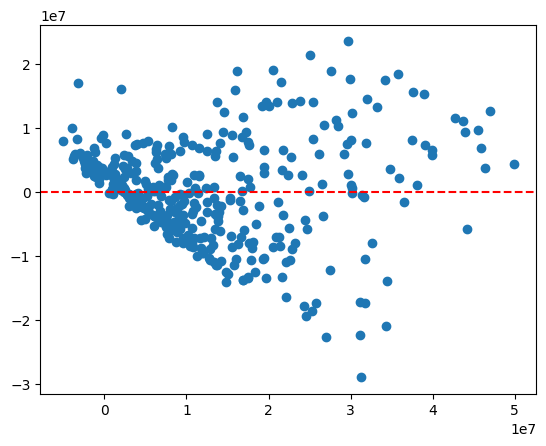

In [202]:
plt.scatter(df_cleaned["OLS_pred"], model.resid)
plt.axhline(y = 0, color = "r", linestyle = "--")
plt.show()

Based on the residual plot, the residuals tend to increase with greater predicted salaries, which makes sense because when the salaries are bigger, proportionally bigger errors are expected. However, I still feel as if these errors increase too much by the time they get to the stars, breaking the condition for equal variance.

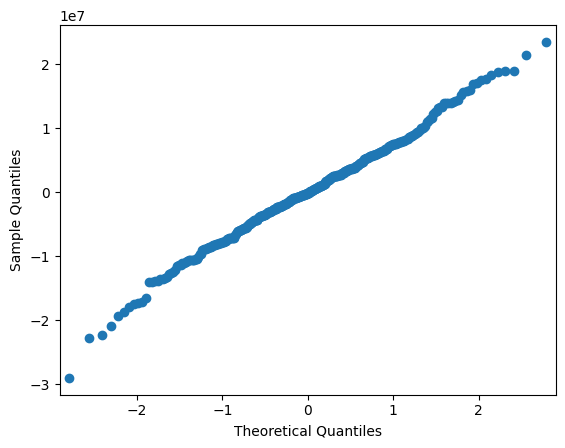

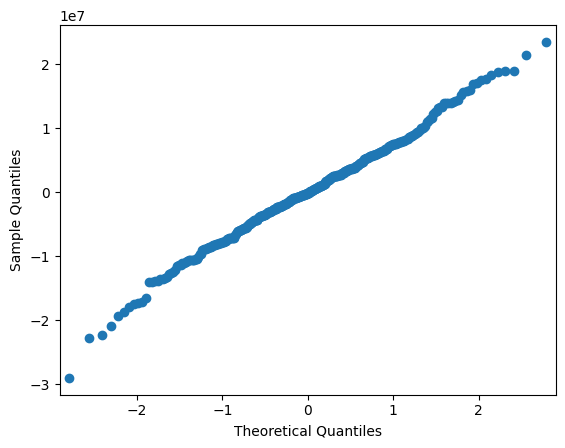

In [203]:
smf2.qqplot(model.resid)

The QQ-Plot loks good which helps to meet the OLS assumption of normality of errors.

In [204]:
df_cleaned[df_cleaned["Player"] == "Jayson Tatum"]

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,Team_salary,salary_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Total_Mins,OLS_pred,Residual
196,Jayson Tatum,32.599998,27,BOS,PF,16,16,7.4,17.9,0.411,...,BOS,54126450.0,58456566.0,62786682.0,67116798.0,71446914.0,NaN,521.599976,3.891435e+07,1.521210e+07


The large RMSE combined with unequal variance at increasing predicted player salaries prompted me to try out a XGBoost model to see if I can get better results.

XGBoost Model

Now, I will try out an XGBoost model for regression. Since XGBoost already minimizes L1 and L2 functions, I will not need to use any feature selection prompts other than the model itself. This model should minimize mean squared error through creating multiple decision trees, each one lowering the residuals from the previous.

In [205]:
XGBmodel = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5
)

In [206]:
x_numeric = x_numeric.rename(columns = {"Total Mins":"Total_Mins"})

In [207]:
XGBmodel.fit(x_numeric, y_var)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [208]:
features = x_numeric.columns
df_cleaned["XGpred"] = XGBmodel.predict(df_cleaned[features])

In [209]:
df_cleaned.head()

,Player,MP,Age_pg,Team_pg,Pos_pg,G_pg,GS_pg,FG_pg,FGA_pg,FGpct_pg,...,salary_2025_26,_2026_27,_2027_28,_2028_29,_2029_30,_2030_31,Total_Mins,OLS_pred,Residual,XGpred
0,A.J. Green,29.100000,26,MIL,SG,78,68,3.4,7.9,0.424,...,2301587.0,10044644.0,10848215.0,11651786.0,12455355.0,NaN,2269.800030,6.077026e+06,-3.775439e+06,2858404.50
7,AJ Johnson,9.500000,21,2TM,SG,48,0,1.2,3.7,0.324,...,3090480.0,3237120.0,5493394.0,NaN,NaN,NaN,456.000000,-7.091789e+05,3.799659e+06,3234234.75
1,Aaron Gordon,27.900000,30,DEN,PF,36,33,5.5,11.1,0.497,...,22841455.0,33658037.0,36350680.0,39043323.0,NaN,NaN,1004.399986,2.659879e+07,-3.757330e+06,23478092.00
2,Aaron Holiday,13.700000,29,HOU,PG,57,1,1.8,4.4,0.417,...,2296274.0,NaN,NaN,NaN,NaN,NaN,780.899989,5.227101e+06,-2.930827e+06,3752267.00
3,Aaron Nesmith,29.700001,26,IND,SF,45,42,4.7,11.4,0.414,...,11000000.0,11000000.0,19418000.0,20971440.0,NaN,NaN,1336.500034,1.704543e+07,-6.045430e+06,11772995.00


In [210]:
df_cleaned["XGresid"] = df_cleaned["salary_2025_26"] - df_cleaned["XGpred"]

In [216]:
root_mean_squared_error(df_cleaned["salary_2025_26"], df_cleaned["XGpred"])

919924.7806904746

In [217]:
XGBmodel.score(x_numeric, y_var)

0.9955416703382433

The XGBoost model performed signicantly better than the OLS model. The XGBoost model had an RMSE of 919924.7806904746 which is signifcantly lower than the OLS model's RMSE of 7929796.280924423. Additionally, the XGBoost model had a much higher R-squared value of 0.9955416703382433 compared to the OLS model's R-squared of 0.669. Therefore, I will be using the XGBoost model for my predictions to determine if a player is being overpaid or underpaid.